In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from math import sqrt
import plotly
import plotly.offline as py
from plotly.offline import plot, iplot
plotly.offline.init_notebook_mode(connected=True)
from yellowbrick.features import FeatureImportances
#from pycaret.classification import *
import sqlalchemy
from sqlalchemy import create_engine
import joblib
import plotly.express as px

#biblioteca para lidar com classes desbalanceadas. 
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

# Testes estatísticos
from scipy.stats import chi2_contingency, mannwhitneyu
import scipy.stats as stats

# Modelos de machine learning e utilitários
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV, cross_validate
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix, make_scorer
from imblearn.under_sampling import NearMiss
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
#import category_encoders as ce
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

# Classificadores e métodos de ensemble
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.preprocessing import StandardScaler, MaxAbsScaler, MinMaxScaler, Normalizer, RobustScaler

pd.set_option('display.max_columns', None)

In [5]:
# ── Config ────────────────────────────────────────────────────────────────────
df = pd.read_csv('~/Projeto/Portfolio/Portfolio2/Churn/data/telco.csv')
df

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,Zip Code,Latitude,Longitude,Population,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,Los Angeles,90022,34.023810,-118.156582,68701,Q3,No,0,1,NaN,No,0.00,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,Los Angeles,90063,34.044271,-118.185237,55668,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,Los Angeles,90065,34.108833,-118.229715,47534,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,Inglewood,90303,33.936291,-118.332639,27778,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,Whittier,90602,33.972119,-118.020188,26265,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,Female,30,No,No,No,No,0,United States,California,Landers,92285,34.341737,-116.539416,2182,Q3,No,0,72,NaN,Yes,22.77,No,No,NaN,0,No,No,No,No,No,No,No,No,Two Year,Yes,Bank Withdrawal,21.15,1419.40,19.31,0,1639.44,3039.53,5,Stayed,No,45,5306,NaN,NaN
7039,6840-RESVB,Male,38,No,No,Yes,Yes,2,United States,California,Adelanto,92301,34.667815,-117.536183,18980,Q3,Yes,1,24,Offer C,Yes,36.05,Yes,Yes,Cable,24,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,One Year,Yes,Mailed Check,84.80,1990.50,48.23,0,865.20,2807.47,3,Stayed,No,59,2140,NaN,NaN
7040,2234-XADUH,Female,30,No,No,Yes,Yes,2,United States,California,Amboy,92304,34.559882,-115.637164,42,Q3,Yes,4,72,NaN,Yes,29.66,Yes,Yes,Fiber Optic,59,No,Yes,Yes,No,Yes,Yes,Yes,Yes,One Year,Yes,Credit Card,103.20,7362.90,45.38,0,2135.52,9453.04,4,Stayed,No,71,5560,NaN,NaN
7041,4801-JZAZL,Female,32,No,No,Yes,Yes,2,United States,California,Angelus Oaks,92305,34.167800,-116.864330,301,Q3,Yes,1,11,NaN,No,0.00,No,Yes,DSL,17,Yes,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,29.60,346.45,27.24,0,0.00,319.21,4,Stayed,No,59,2793,NaN,NaN


In [6]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Number of Dependents', 'Country', 'State', 'City',
       'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'],
      dtype='object')

In [8]:
cols_to_drop = [
    
    # identificador
    "Customer ID",
    
    # target e derivados
    "Customer Status",
    "Churn Label",
    "Churn Score",
    "Churn Category",
    "Churn Reason",
    "CLTV",
    
    # geolocalização detalhada
    "Zip Code",
    "Latitude",
    "Longitude",
    
]

In [18]:
# Definindo random_state para reprodutibilidade
random_state = 42

y = (df["Churn Label"] == "Yes").astype(int)
X = df.drop(columns=cols_to_drop)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=random_state
)


In [19]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler

class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.q_low_ = X.quantile(self.lower)
        self.q_high_ = X.quantile(self.upper)
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.clip(self.q_low_, self.q_high_, axis=1)
    
# Defina os transformadores para colunas numéricas e categóricas
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_features = X_train.select_dtypes(include=['object']).columns

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('outliers', QuantileClipper(0.00, 1.00)),
    ('scaler', StandardScaler())  # depois vamos trocar
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop=None, handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ]
)

# Define the scalers and models
scalers = {
    'None': None,
    'MaxAbsScaler': MaxAbsScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'Normalizer': Normalizer(),
    'RobustScaler': RobustScaler(),
    'StandardScaler': StandardScaler()
}

models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=random_state),
    'Logistic Regression': LogisticRegression(solver='liblinear', random_state=random_state),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=random_state),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=random_state),
    'LightGBM': LGBMClassifier(random_state=random_state),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=5, random_state=random_state)
}

Scaler: None, Model: Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1009
           1       0.93      0.84      0.88       400

    accuracy                           0.94      1409
   macro avg       0.93      0.91      0.92      1409
weighted avg       0.94      0.94      0.94      1409


------------------------------------------------------------



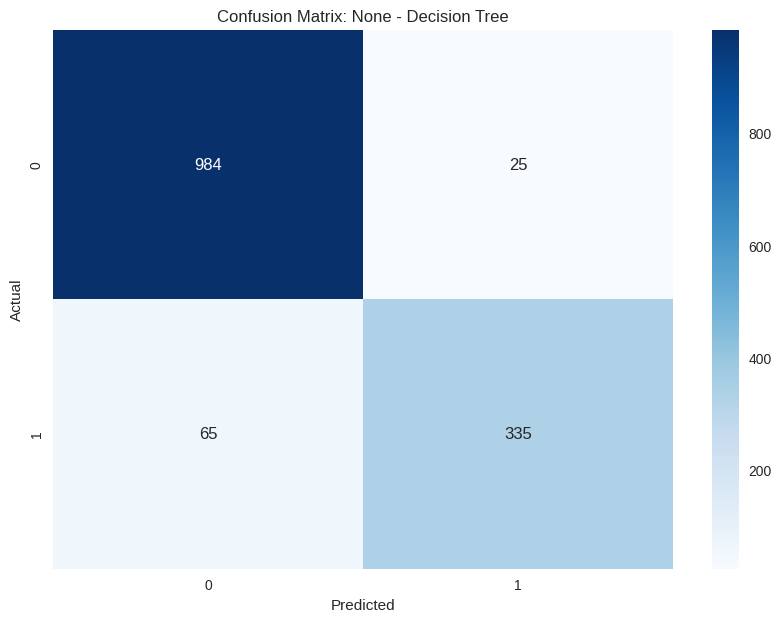

Scaler: None, Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1009
           1       0.94      0.90      0.92       400

    accuracy                           0.96      1409
   macro avg       0.95      0.94      0.94      1409
weighted avg       0.96      0.96      0.96      1409


------------------------------------------------------------



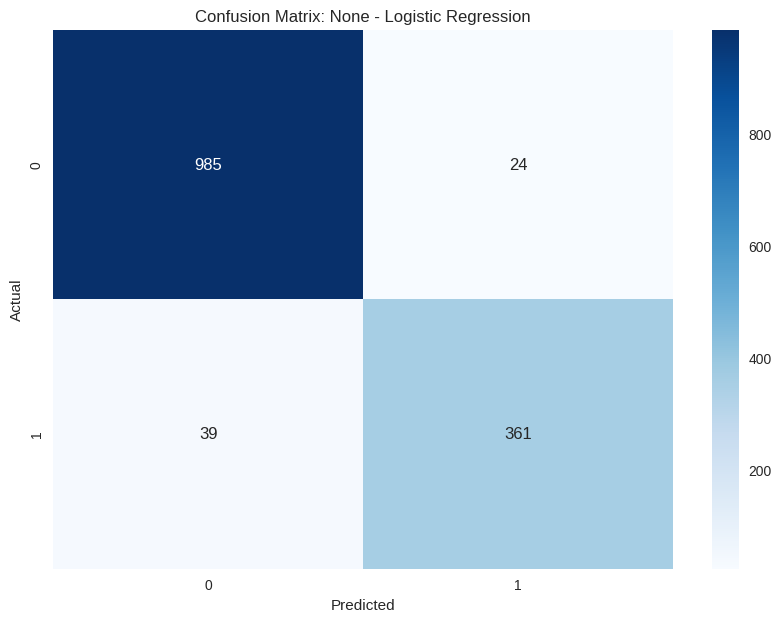

Scaler: None, Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      1009
           1       0.95      0.82      0.88       400

    accuracy                           0.94      1409
   macro avg       0.94      0.90      0.92      1409
weighted avg       0.94      0.94      0.94      1409


------------------------------------------------------------



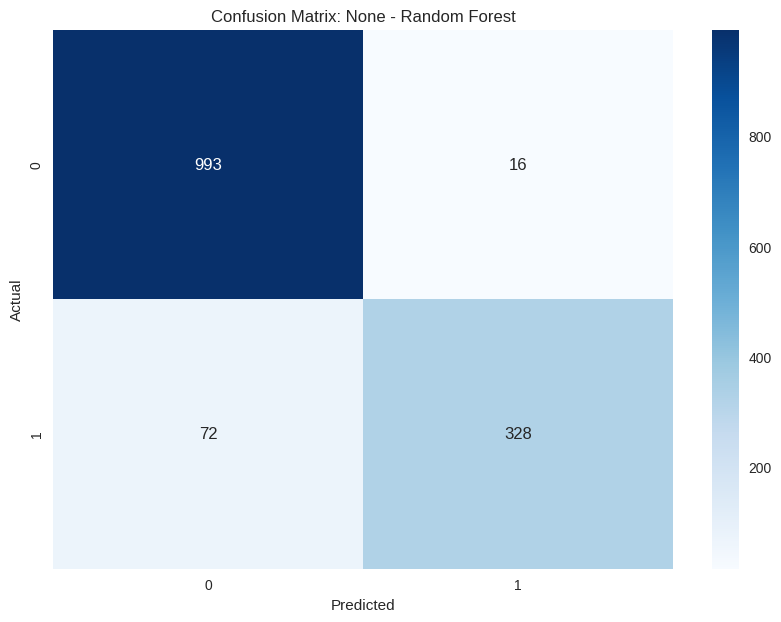

Scaler: None, Model: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1009
           1       0.97      0.87      0.92       400

    accuracy                           0.96      1409
   macro avg       0.96      0.93      0.94      1409
weighted avg       0.96      0.96      0.96      1409


------------------------------------------------------------



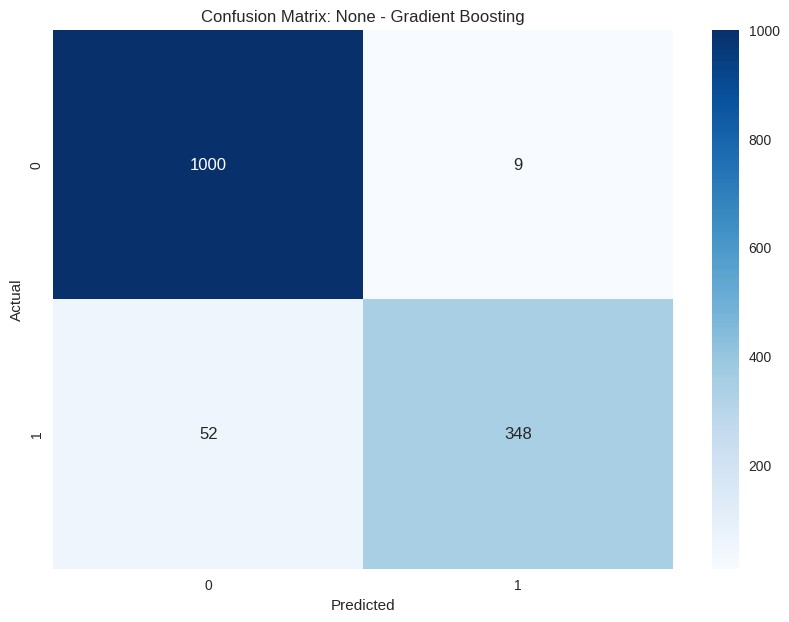

[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000373 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2013
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260706 -> initscore=-1.042305
[LightGBM] [Info] Start training from score -1.042305
[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000282 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2006
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 80
[LightGBM] [Info] [binar

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000293 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2012
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 81
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260706 -> initscore=-1.042305
[LightGBM] [Info] Start training from score -1.042305
[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000288 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2009
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 82
[LightGBM] [Info] [binar

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 1176, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000282 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2014
[LightGBM] [Info] Number of data points in the train set: 4508, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260870 -> initscore=-1.041454
[LightGBM] [Info] Start training from score -1.041454
[LightGBM] [Info] Number of positive: 1469, number of negative: 4165
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000343 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2059
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 92
[LightGBM] [Info] [binar

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 1469, number of negative: 4165
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000339 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2059
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 92
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260738 -> initscore=-1.042134
[LightGBM] [Info] Start training from score -1.042134

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1009
           1       0.95      0.89      0.92       400

    accuracy                           0.95      1409
   macro avg       0.95      0.93      0.94      1409
weighted avg       0.95      0.95      0.95      1409


------------------------------------------------------------



/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



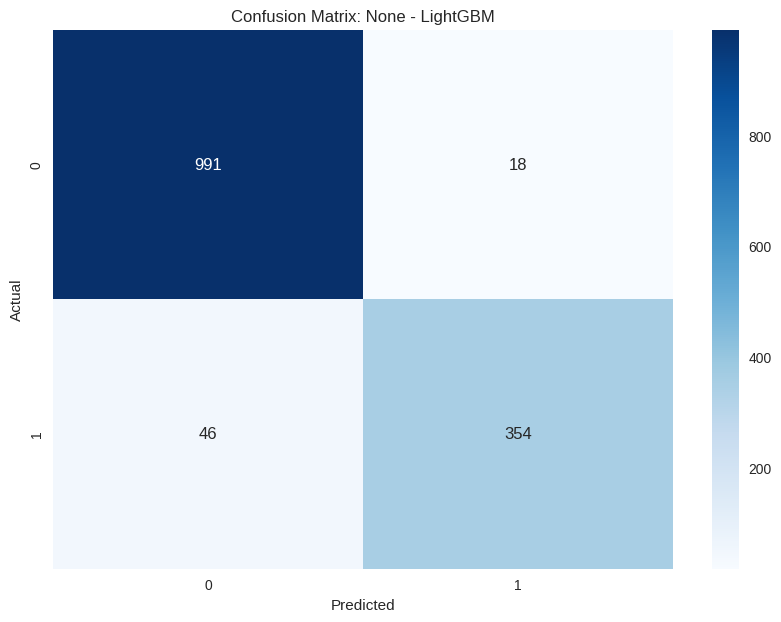

Scaler: None, Model: XGBoost

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1009
           1       0.94      0.87      0.91       400

    accuracy                           0.95      1409
   macro avg       0.95      0.93      0.93      1409
weighted avg       0.95      0.95      0.95      1409


------------------------------------------------------------



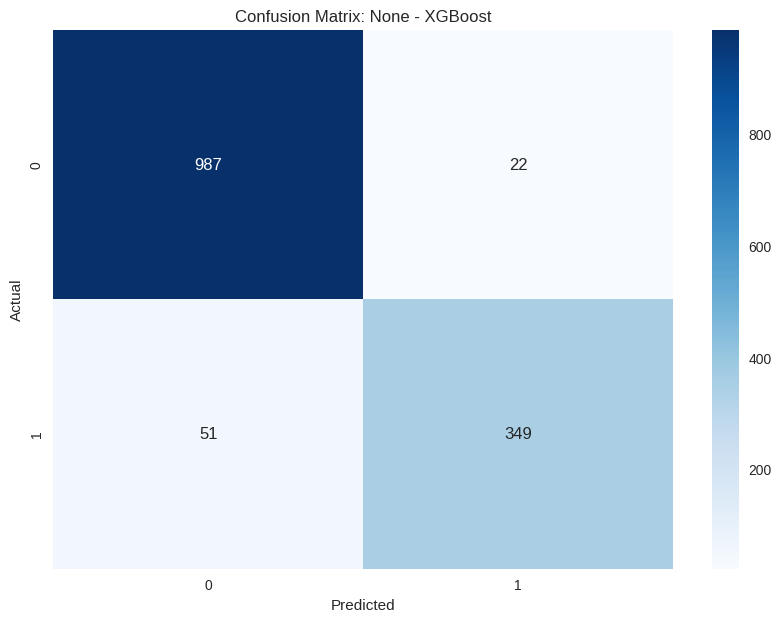

Scaler: MaxAbsScaler, Model: Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1009
           1       0.93      0.84      0.88       400

    accuracy                           0.94      1409
   macro avg       0.93      0.91      0.92      1409
weighted avg       0.94      0.94      0.94      1409


------------------------------------------------------------



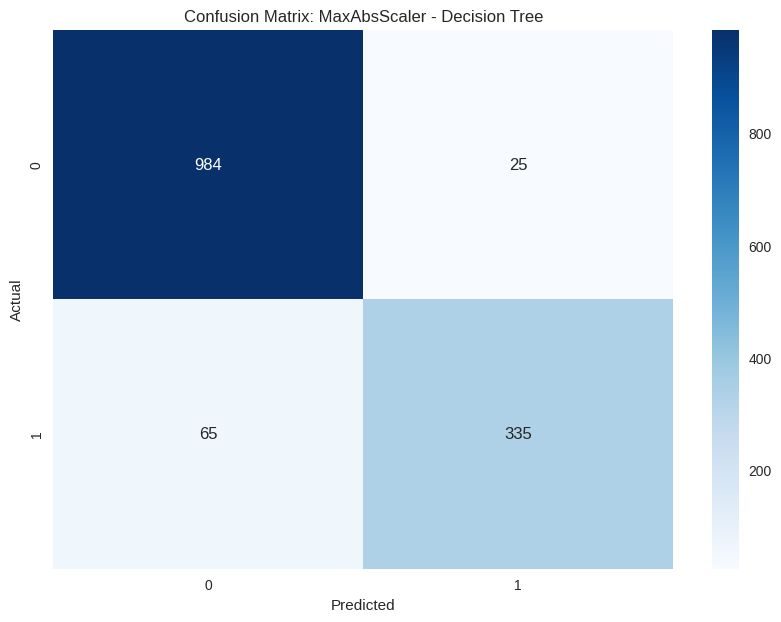

Scaler: MaxAbsScaler, Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1009
           1       0.93      0.90      0.91       400

    accuracy                           0.95      1409
   macro avg       0.95      0.93      0.94      1409
weighted avg       0.95      0.95      0.95      1409


------------------------------------------------------------



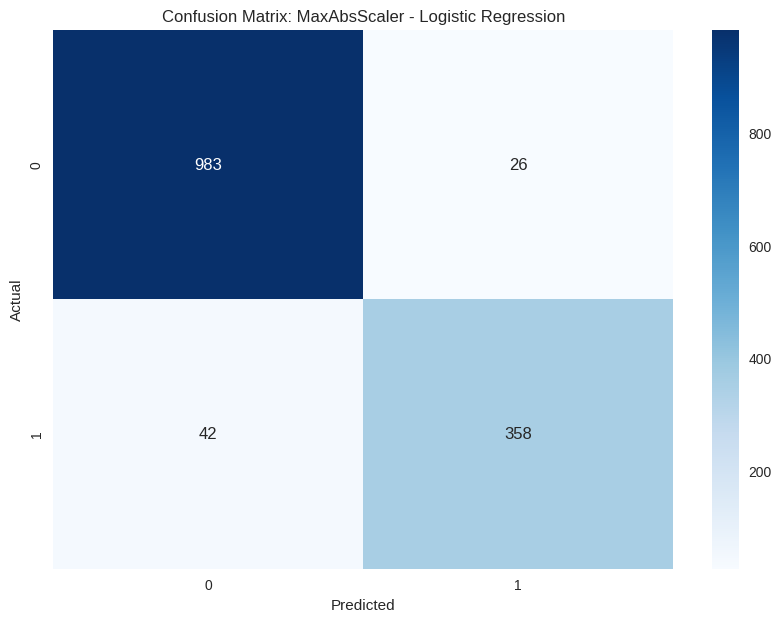

Scaler: MaxAbsScaler, Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      1009
           1       0.96      0.82      0.88       400

    accuracy                           0.94      1409
   macro avg       0.94      0.90      0.92      1409
weighted avg       0.94      0.94      0.94      1409


------------------------------------------------------------



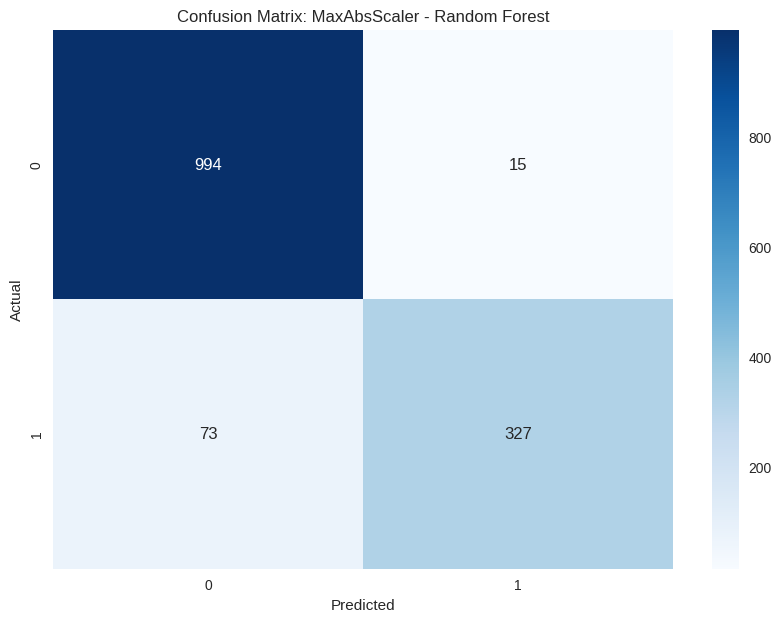

Scaler: MaxAbsScaler, Model: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1009
           1       0.97      0.87      0.92       400

    accuracy                           0.96      1409
   macro avg       0.96      0.93      0.94      1409
weighted avg       0.96      0.96      0.96      1409


------------------------------------------------------------



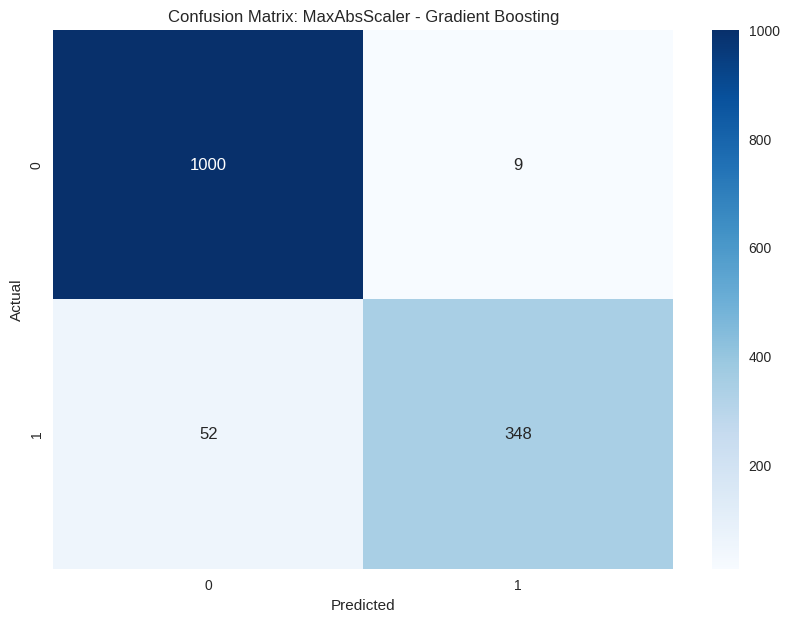

[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000369 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2013
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260706 -> initscore=-1.042305
[LightGBM] [Info] Start training from score -1.042305
[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000279 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2006
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 80
[LightGBM] [Info] [binar

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000288 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2012
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 81
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260706 -> initscore=-1.042305
[LightGBM] [Info] Start training from score -1.042305
[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000290 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2009
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 82
[LightGBM] [Info] [binar

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 1176, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000283 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2014
[LightGBM] [Info] Number of data points in the train set: 4508, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260870 -> initscore=-1.041454
[LightGBM] [Info] Start training from score -1.041454
[LightGBM] [Info] Number of positive: 1469, number of negative: 4165
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000345 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2059
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 92
[LightGBM] [Info] [binar

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



Scaler: MaxAbsScaler, Model: LightGBM
[LightGBM] [Info] Number of positive: 1469, number of negative: 4165
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000342 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2059
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 92
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260738 -> initscore=-1.042134
[LightGBM] [Info] Start training from score -1.042134

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1009
           1       0.95      0.89      0.92       400

    accuracy                           0.95      1409
   macro avg       0.95      0.93      0.94      1409
weighted avg       0.95      0.95      0.95      1409


-------------------------------------------------------

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



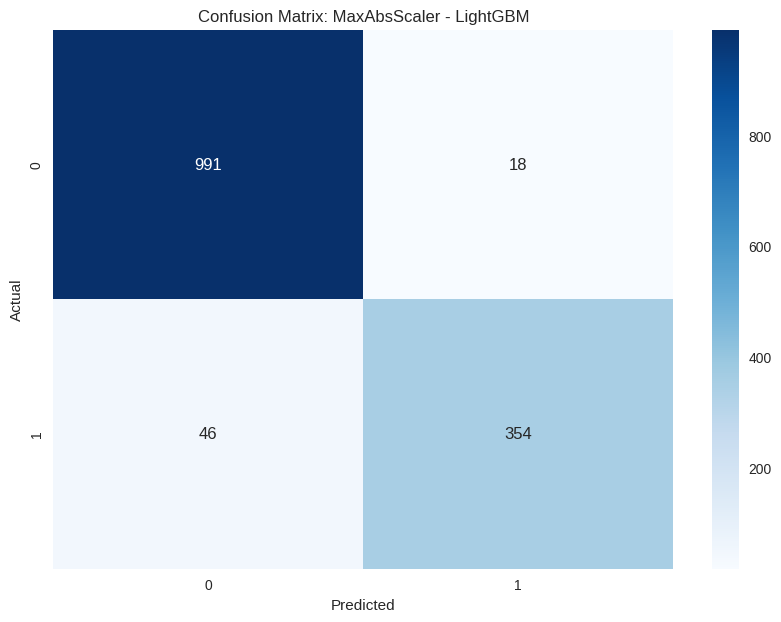

Scaler: MaxAbsScaler, Model: XGBoost

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1009
           1       0.94      0.87      0.91       400

    accuracy                           0.95      1409
   macro avg       0.95      0.93      0.93      1409
weighted avg       0.95      0.95      0.95      1409


------------------------------------------------------------



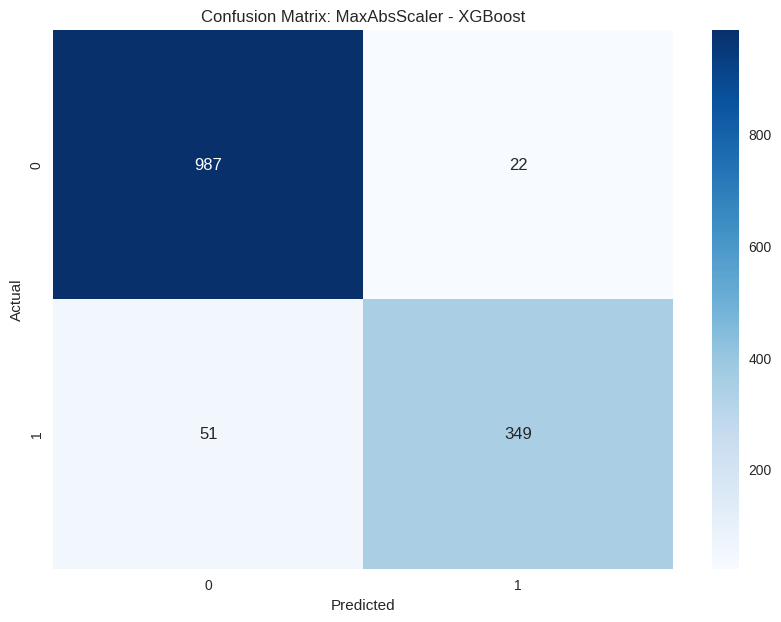

Scaler: MinMaxScaler, Model: Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1009
           1       0.93      0.84      0.88       400

    accuracy                           0.94      1409
   macro avg       0.93      0.91      0.92      1409
weighted avg       0.94      0.94      0.94      1409


------------------------------------------------------------



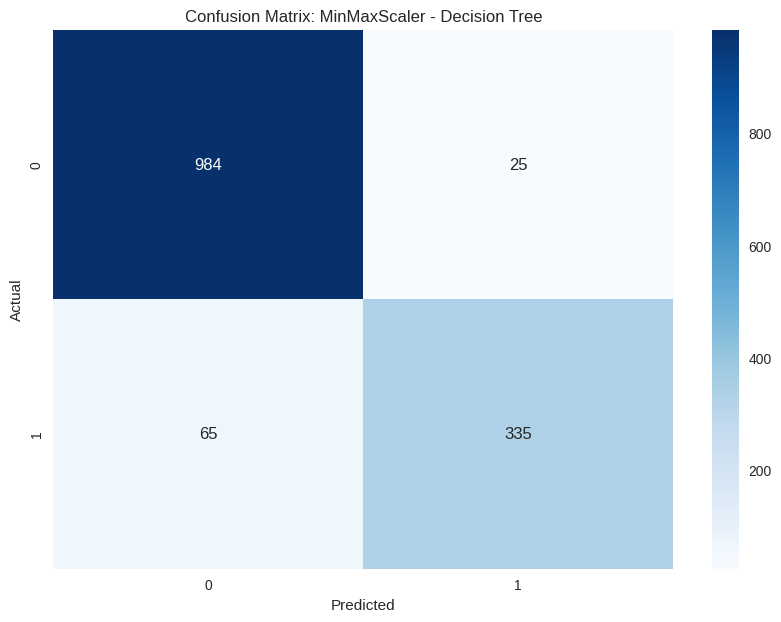

Scaler: MinMaxScaler, Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1009
           1       0.94      0.89      0.92       400

    accuracy                           0.95      1409
   macro avg       0.95      0.93      0.94      1409
weighted avg       0.95      0.95      0.95      1409


------------------------------------------------------------



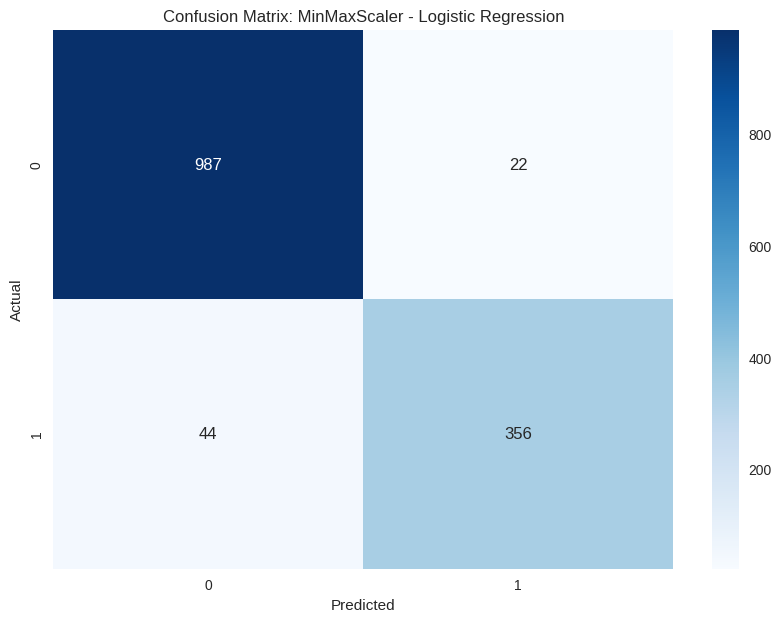

Scaler: MinMaxScaler, Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1009
           1       0.95      0.83      0.89       400

    accuracy                           0.94      1409
   macro avg       0.94      0.91      0.92      1409
weighted avg       0.94      0.94      0.94      1409


------------------------------------------------------------



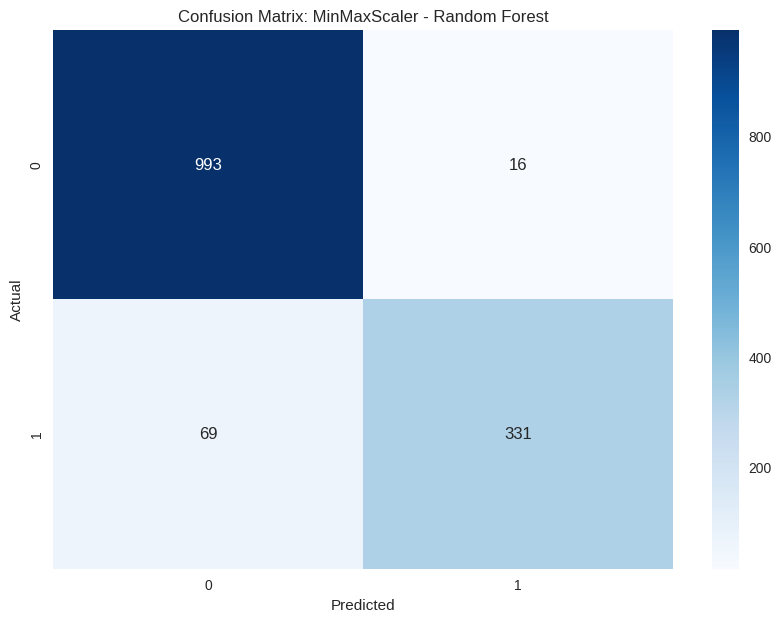

Scaler: MinMaxScaler, Model: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1009
           1       0.97      0.87      0.92       400

    accuracy                           0.96      1409
   macro avg       0.96      0.93      0.94      1409
weighted avg       0.96      0.96      0.96      1409


------------------------------------------------------------



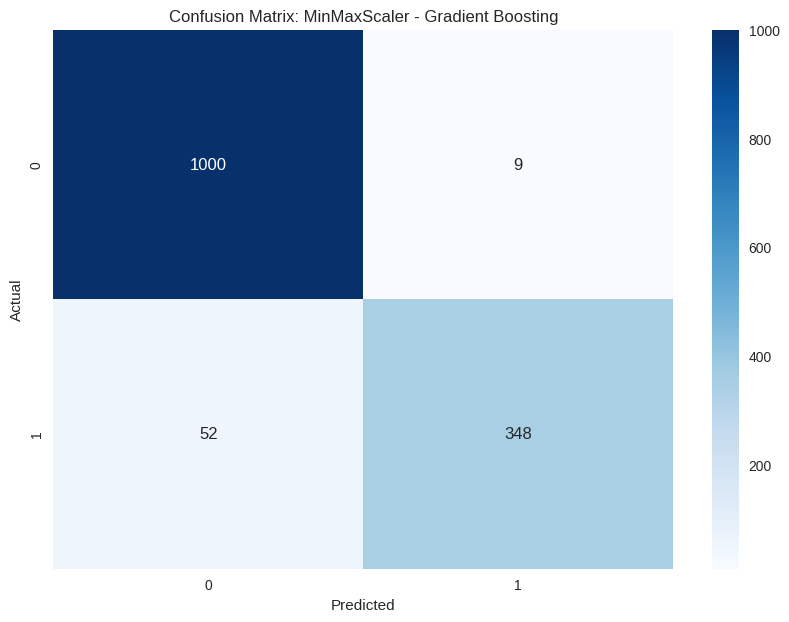

[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000357 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2005
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260706 -> initscore=-1.042305
[LightGBM] [Info] Start training from score -1.042305
[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000485 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1997
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 80
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260706 -> initscore=-1.042305
[LightGB

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000297 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2004
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 81
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260706 -> initscore=-1.042305
[LightGBM] [Info] Start training from score -1.042305
[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000281 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2000
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 82
[LightGBM] [Info] [binar

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 1176, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000288 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2006
[LightGBM] [Info] Number of data points in the train set: 4508, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260870 -> initscore=-1.041454
[LightGBM] [Info] Start training from score -1.041454
[LightGBM] [Info] Number of positive: 1469, number of negative: 4165
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000536 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2052
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 92
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260738 -> initscore=-1.042134
[LightGB

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



Scaler: MinMaxScaler, Model: LightGBM
[LightGBM] [Info] Number of positive: 1469, number of negative: 4165
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000331 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2052
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 92
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260738 -> initscore=-1.042134
[LightGBM] [Info] Start training from score -1.042134

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1009
           1       0.94      0.88      0.91       400

    accuracy                           0.95      1409
   macro avg       0.94      0.93      0.94      1409
weighted avg       0.95      0.95      0.95      1409


-------------------------------------------------------

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



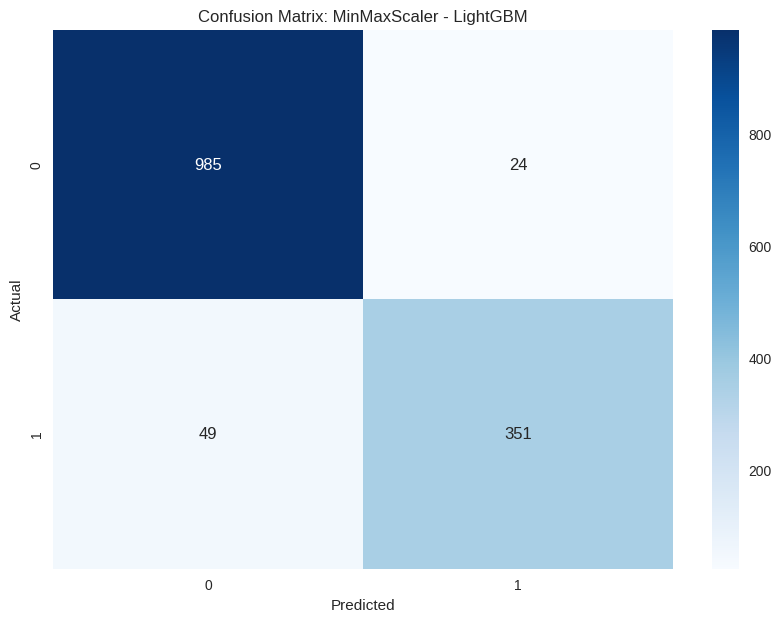

Scaler: MinMaxScaler, Model: XGBoost

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1009
           1       0.94      0.87      0.91       400

    accuracy                           0.95      1409
   macro avg       0.95      0.93      0.93      1409
weighted avg       0.95      0.95      0.95      1409


------------------------------------------------------------



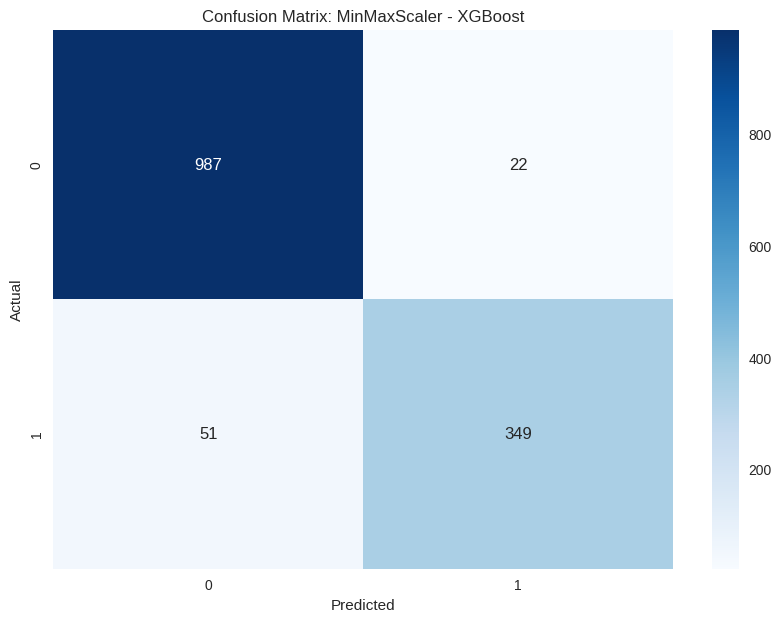

Scaler: Normalizer, Model: Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      1009
           1       0.93      0.82      0.87       400

    accuracy                           0.93      1409
   macro avg       0.93      0.90      0.91      1409
weighted avg       0.93      0.93      0.93      1409


------------------------------------------------------------



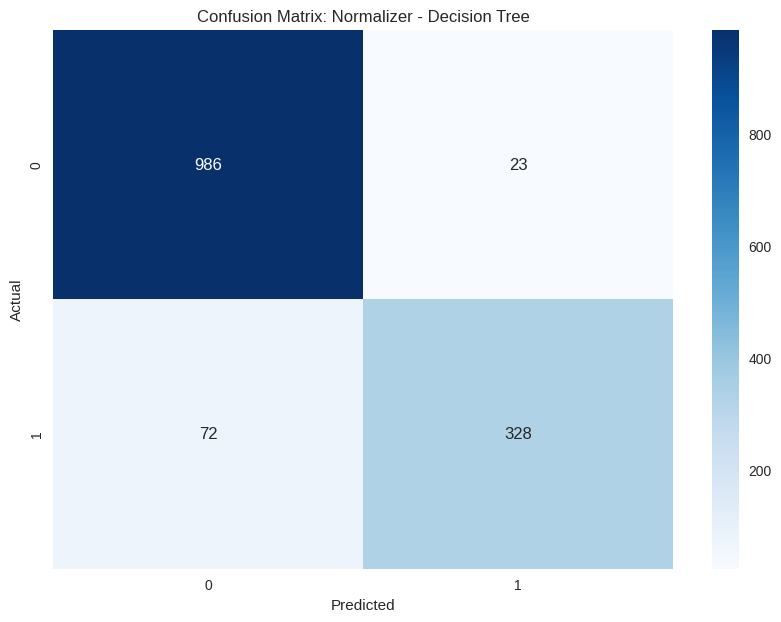

Scaler: Normalizer, Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1009
           1       0.95      0.86      0.90       400

    accuracy                           0.95      1409
   macro avg       0.95      0.92      0.93      1409
weighted avg       0.95      0.95      0.95      1409


------------------------------------------------------------



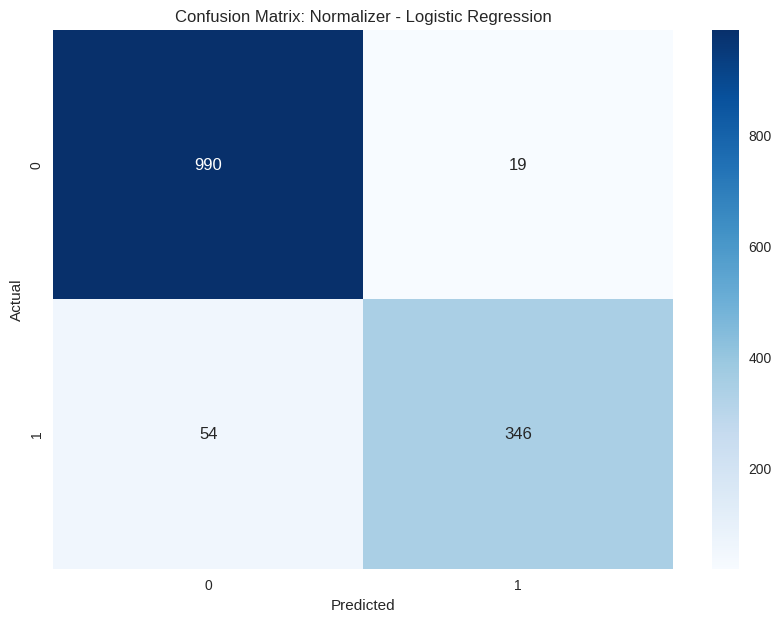

Scaler: Normalizer, Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      1009
           1       0.96      0.77      0.85       400

    accuracy                           0.92      1409
   macro avg       0.94      0.88      0.90      1409
weighted avg       0.93      0.92      0.92      1409


------------------------------------------------------------



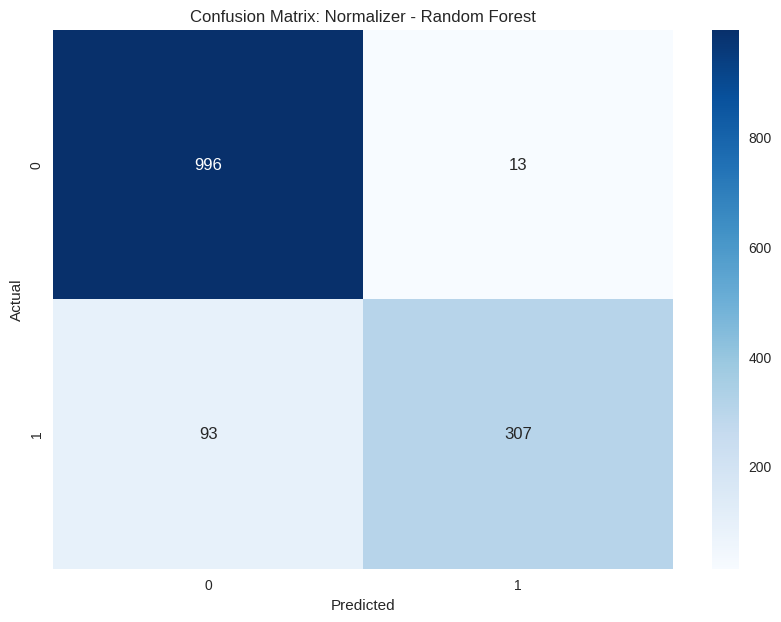

Scaler: Normalizer, Model: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1009
           1       0.97      0.86      0.91       400

    accuracy                           0.95      1409
   macro avg       0.96      0.92      0.94      1409
weighted avg       0.95      0.95      0.95      1409


------------------------------------------------------------



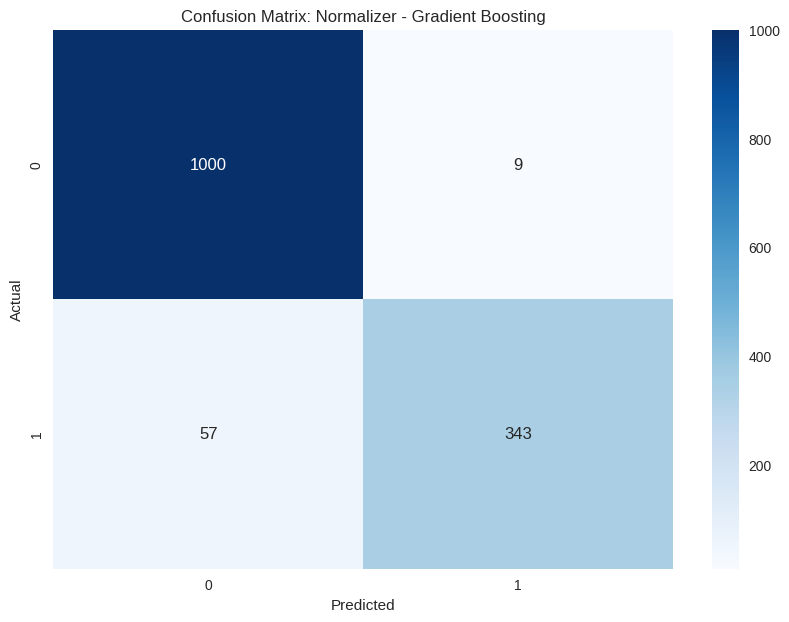

[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000400 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16546
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 86
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260706 -> initscore=-1.042305
[LightGBM] [Info] Start training from score -1.042305
[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000410 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16526
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260706 -> initscore=-1.042305
[LightGBM] [Info] Start training from score -1.042305


/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000428 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16533
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 84
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260706 -> initscore=-1.042305
[LightGBM] [Info] Start training from score -1.042305
[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000437 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16516
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260706 -> initscore=-1.042305
[LightGBM] [Info] Start training from score -1.042305


/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 1176, number of negative: 3332
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000432 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16527
[LightGBM] [Info] Number of data points in the train set: 4508, number of used features: 86
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260870 -> initscore=-1.041454
[LightGBM] [Info] Start training from score -1.041454
[LightGBM] [Info] Number of positive: 1469, number of negative: 4165
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000483 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16928
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 95
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260738 -> initscore=-1.042134
[LightGBM] [Info] Start training from score -1.042134


/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



Scaler: Normalizer, Model: LightGBM
[LightGBM] [Info] Number of positive: 1469, number of negative: 4165
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000455 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16928
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 95
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260738 -> initscore=-1.042134
[LightGBM] [Info] Start training from score -1.042134

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1009
           1       0.95      0.89      0.92       400

    accuracy                           0.95      1409
   macro avg       0.95      0.93      0.94      1409
weighted avg       0.95      0.95      0.95      1409


------------------------------------------------------------



/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



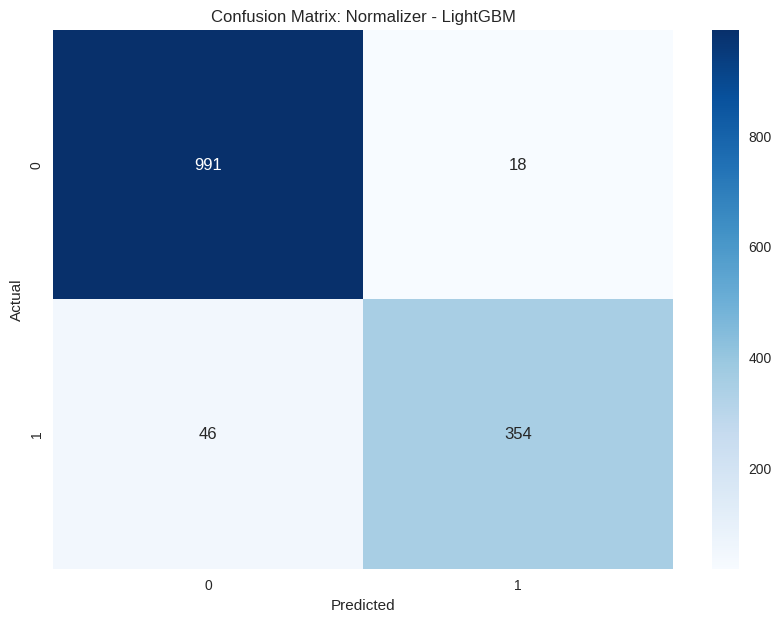

Scaler: Normalizer, Model: XGBoost

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1009
           1       0.95      0.86      0.90       400

    accuracy                           0.95      1409
   macro avg       0.95      0.92      0.93      1409
weighted avg       0.95      0.95      0.95      1409


------------------------------------------------------------



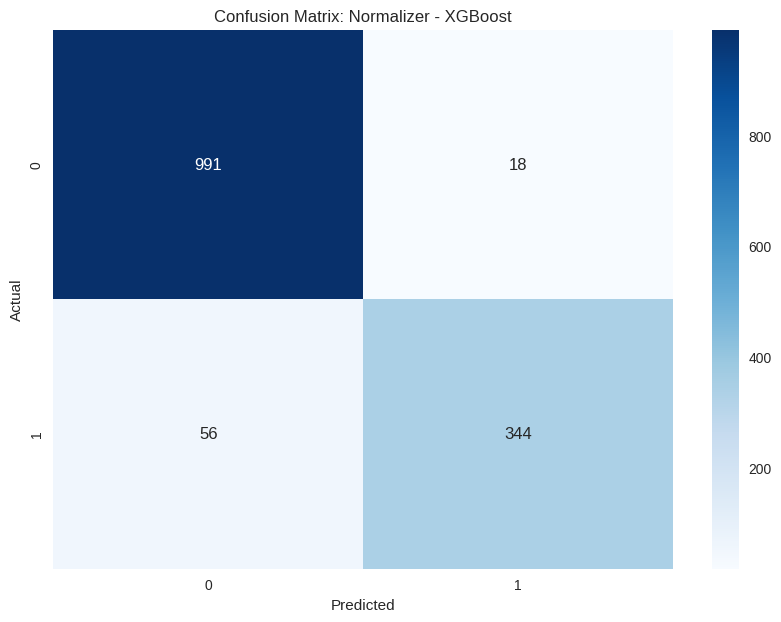

Scaler: RobustScaler, Model: Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1009
           1       0.93      0.84      0.88       400

    accuracy                           0.94      1409
   macro avg       0.93      0.91      0.92      1409
weighted avg       0.94      0.94      0.94      1409


------------------------------------------------------------



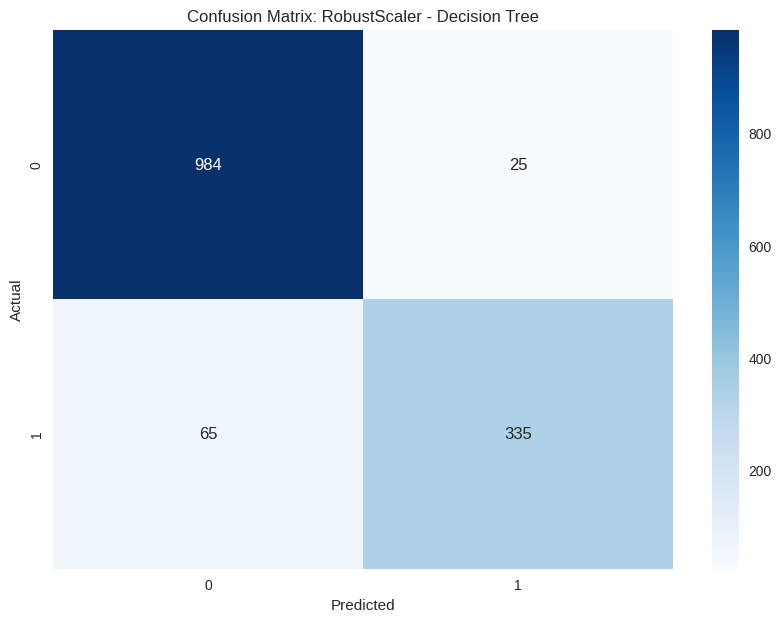

Scaler: RobustScaler, Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1009
           1       0.94      0.91      0.92       400

    accuracy                           0.96      1409
   macro avg       0.95      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409


------------------------------------------------------------



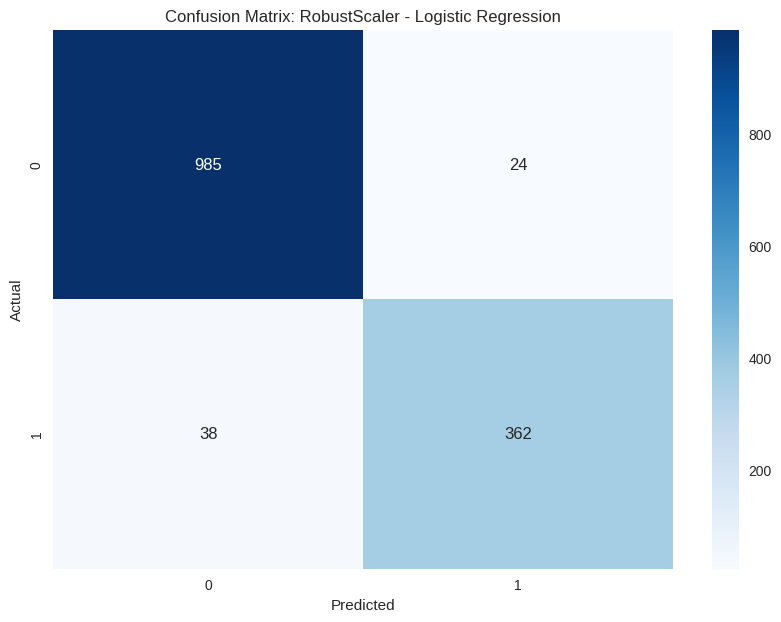

Scaler: RobustScaler, Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1009
           1       0.95      0.83      0.89       400

    accuracy                           0.94      1409
   macro avg       0.94      0.91      0.92      1409
weighted avg       0.94      0.94      0.94      1409


------------------------------------------------------------



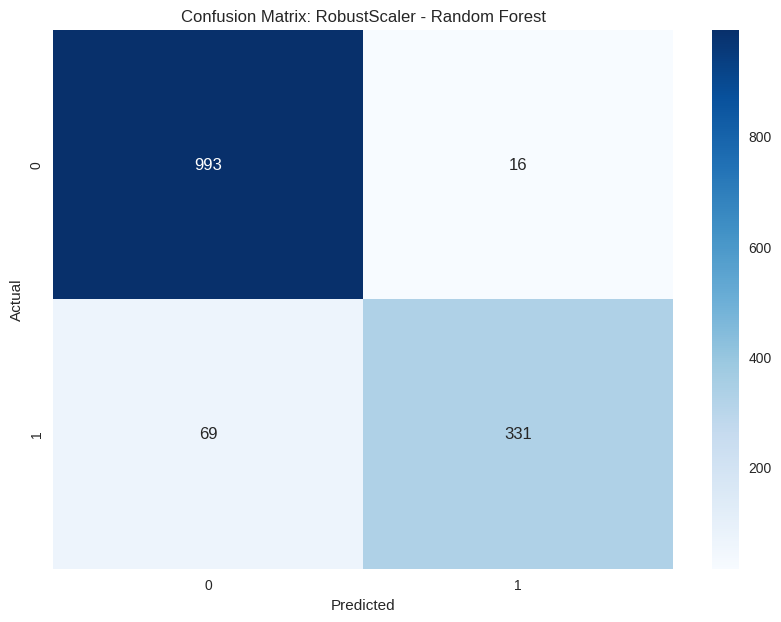

Scaler: RobustScaler, Model: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1009
           1       0.97      0.87      0.92       400

    accuracy                           0.96      1409
   macro avg       0.96      0.93      0.94      1409
weighted avg       0.96      0.96      0.96      1409


------------------------------------------------------------



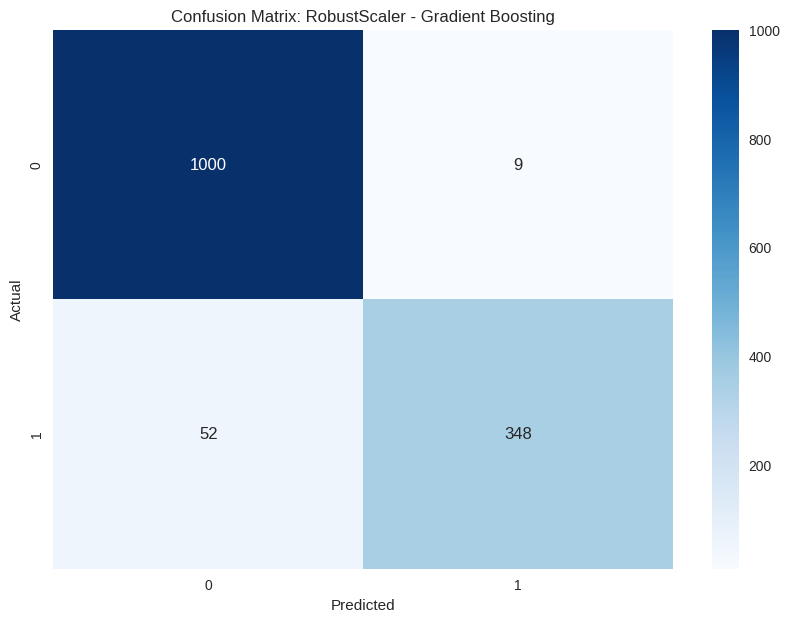

[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000459 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2005
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260706 -> initscore=-1.042305
[LightGBM] [Info] Start training from score -1.042305


/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000435 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1997
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 80
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260706 -> initscore=-1.042305
[LightGBM] [Info] Start training from score -1.042305


/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000434 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2004
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 81
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260706 -> initscore=-1.042305
[LightGBM] [Info] Start training from score -1.042305


...

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 1176, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000449 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2006
[LightGBM] [Info] Number of data points in the train set: 4508, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260870 -> initscore=-1.041454
[LightGBM] [Info] Start training from score -1.041454


/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 1469, number of negative: 4165
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000673 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2052
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 92
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260738 -> initscore=-1.042134
[LightGBM] [Info] Start training from score -1.042134
Scaler: RobustScaler, Model: LightGBM
[LightGBM] [Info] Number of positive: 1469, number of negative: 4165
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000672 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2052
[LightGBM] [Info] Number of data points in the train set: 5634, number of used

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



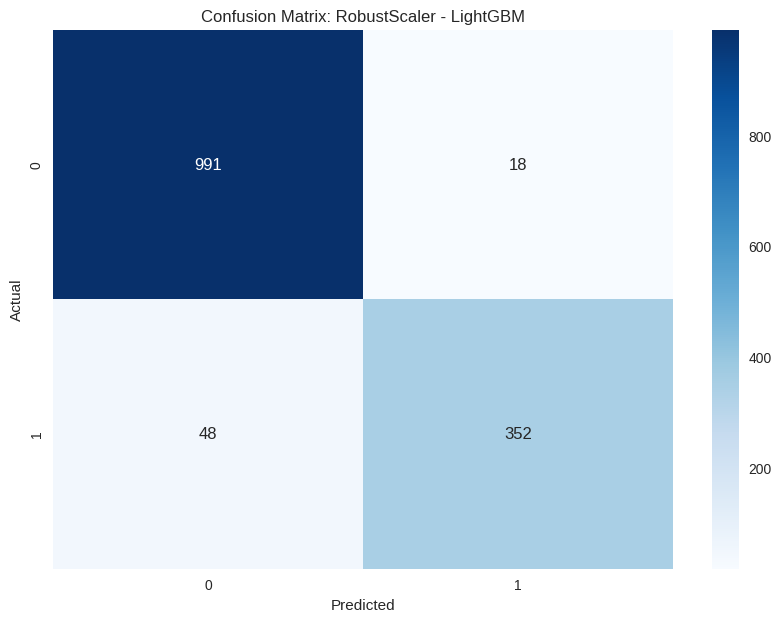

Scaler: RobustScaler, Model: XGBoost

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1009
           1       0.94      0.87      0.91       400

    accuracy                           0.95      1409
   macro avg       0.95      0.93      0.93      1409
weighted avg       0.95      0.95      0.95      1409


------------------------------------------------------------



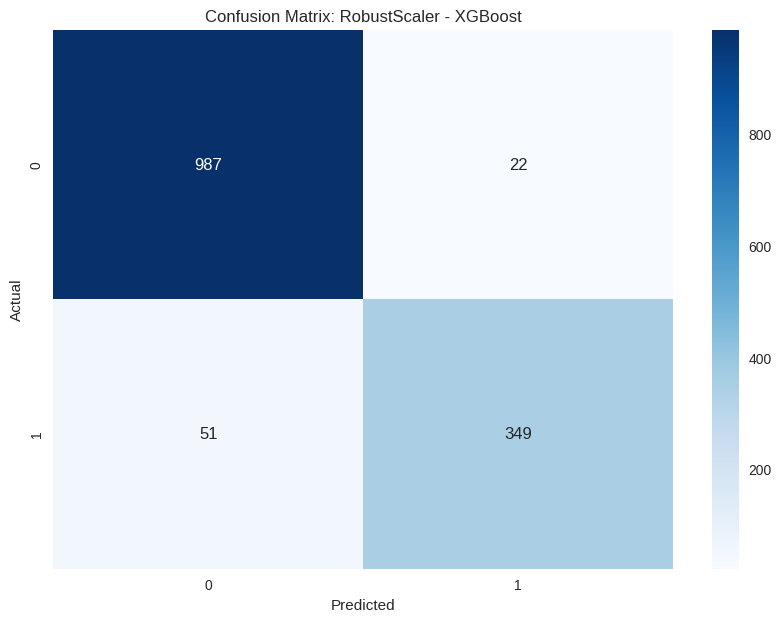

Scaler: StandardScaler, Model: Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1009
           1       0.93      0.84      0.88       400

    accuracy                           0.94      1409
   macro avg       0.93      0.91      0.92      1409
weighted avg       0.94      0.94      0.94      1409


------------------------------------------------------------



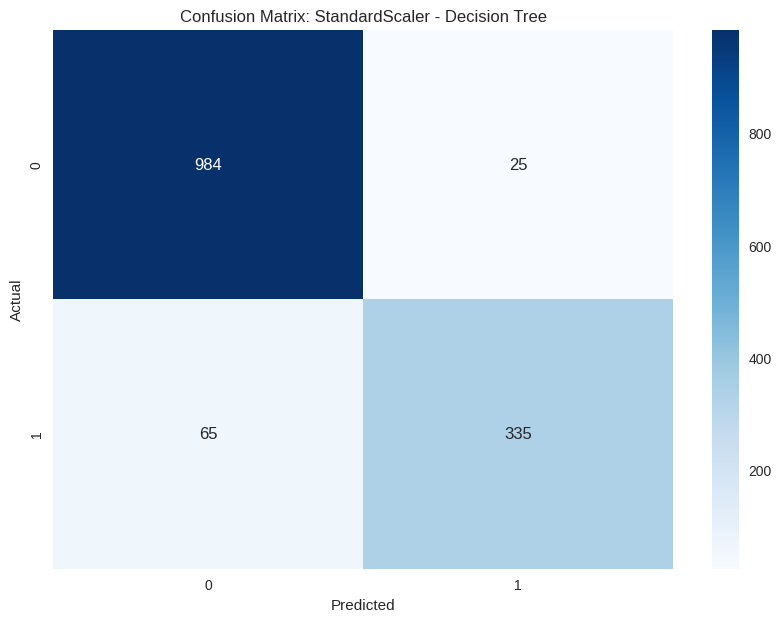

Scaler: StandardScaler, Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94      1009
           1       0.84      0.87      0.86       400

    accuracy                           0.92      1409
   macro avg       0.90      0.90      0.90      1409
weighted avg       0.92      0.92      0.92      1409


------------------------------------------------------------



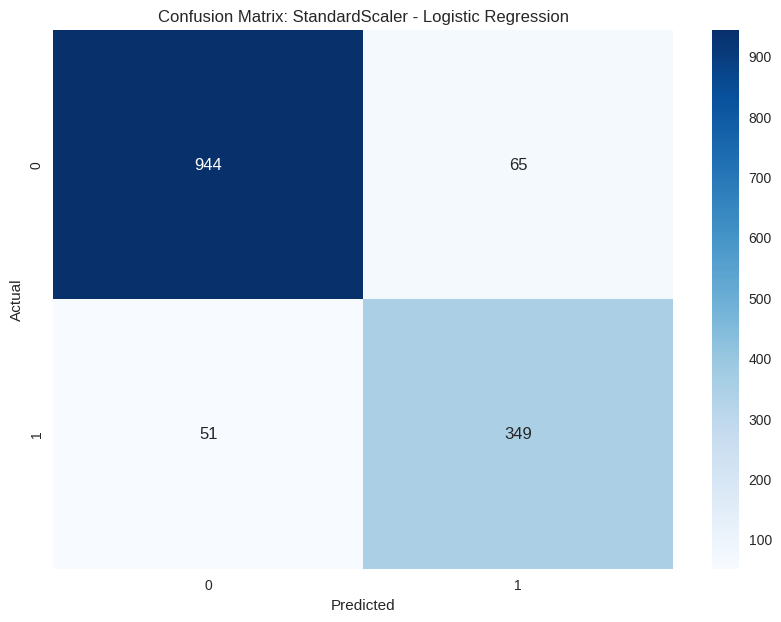

Scaler: StandardScaler, Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      1009
           1       0.95      0.82      0.88       400

    accuracy                           0.94      1409
   macro avg       0.94      0.90      0.92      1409
weighted avg       0.94      0.94      0.94      1409


------------------------------------------------------------



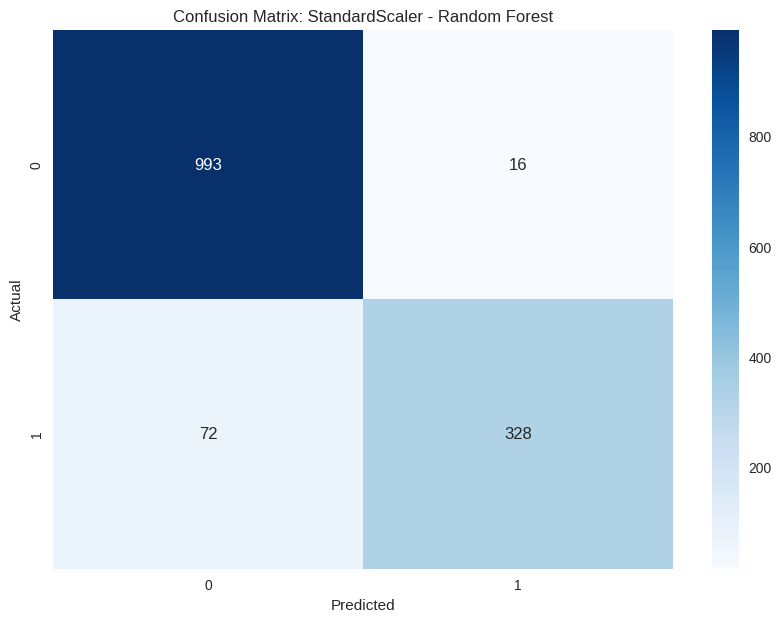

Scaler: StandardScaler, Model: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1009
           1       0.97      0.87      0.92       400

    accuracy                           0.96      1409
   macro avg       0.96      0.93      0.94      1409
weighted avg       0.96      0.96      0.96      1409


------------------------------------------------------------



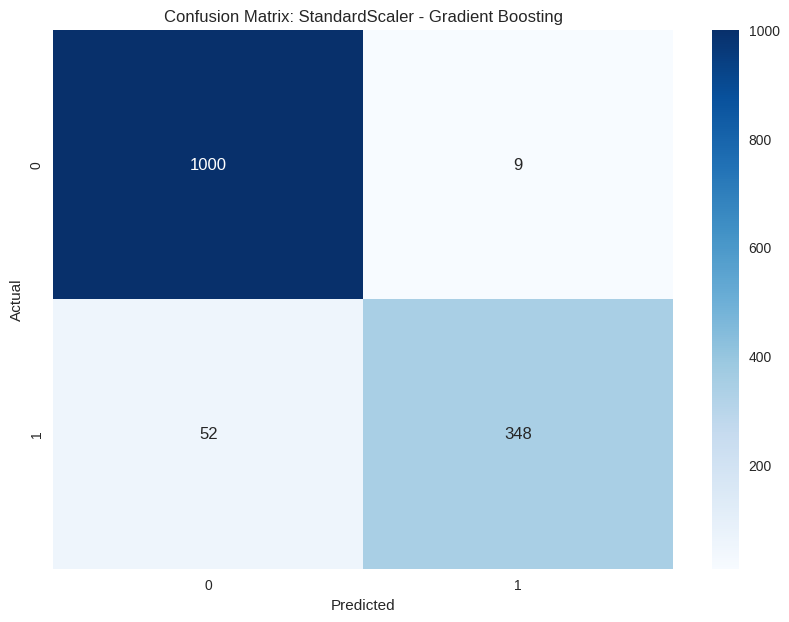

[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000322 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2082
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260706 -> initscore=-1.042305
[LightGBM] [Info] Start training from score -1.042305


/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000318 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2072
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 80
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260706 -> initscore=-1.042305
[LightGBM] [Info] Start training from score -1.042305


/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 1175, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000321 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2079
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 81
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260706 -> initscore=-1.042305
[LightGBM] [Info] Start training from score -1.042305


...

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 1176, number of negative: 3332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000336 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2083
[LightGBM] [Info] Number of data points in the train set: 4508, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260870 -> initscore=-1.041454
[LightGBM] [Info] Start training from score -1.041454


/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 1469, number of negative: 4165
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000386 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2137
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 92
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260738 -> initscore=-1.042134
[LightGBM] [Info] Start training from score -1.042134
Scaler: StandardScaler, Model: LightGBM
[LightGBM] [Info] Number of positive: 1469, number of negative: 4165
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000385 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2137
[LightGBM] [Info] Number of data points in the train set: 5634, number of us

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



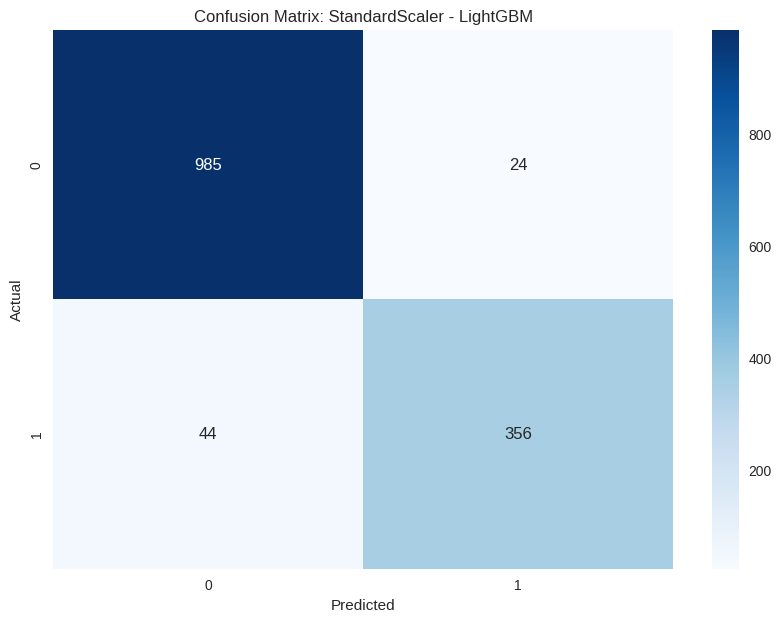

Scaler: StandardScaler, Model: XGBoost

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1009
           1       0.94      0.87      0.91       400

    accuracy                           0.95      1409
   macro avg       0.95      0.93      0.93      1409
weighted avg       0.95      0.95      0.95      1409


------------------------------------------------------------



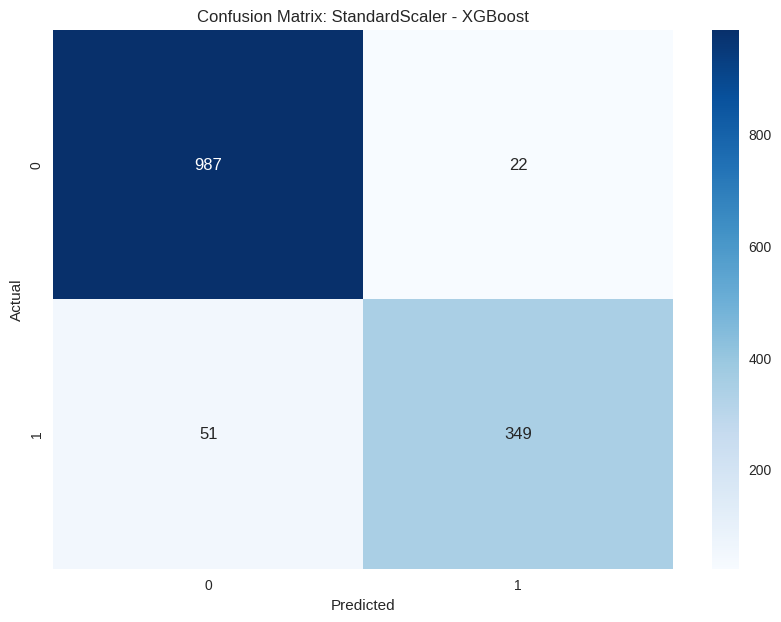

CPU times: user 11min 32s, sys: 26.3 s, total: 11min 58s
Wall time: 6min 10s


,Scaler,Model,Accuracy,Recall,Precision,F1 Score
0,None,Decision Tree,0.951720,0.917108,0.956770,0.934586
1,None,Logistic Regression,0.964324,0.947449,0.959354,0.953130
2,None,Random Forest,0.941603,0.900125,0.946909,0.920179
3,None,Gradient Boosting,0.965211,0.943640,0.965564,0.953758
4,None,LightGBM,0.963792,0.945989,0.959501,0.952346
5,None,XGBoost,0.963791,0.945106,0.960236,0.952253
6,MaxAbsScaler,Decision Tree,0.951720,0.917108,0.956770,0.934586
7,MaxAbsScaler,Logistic Regression,0.963437,0.945529,0.958934,0.951880
8,MaxAbsScaler,Random Forest,0.942313,0.901045,0.947958,0.921129
9,MaxAbsScaler,Gradient Boosting,0.965211,0.943640,0.965564,0.953758


In [20]:
%%time
results = []
pipelines = {}

for scaler_name, scaler in scalers.items():
    for model_name, model in models.items():
        if scaler:
            pipeline = Pipeline(steps=[
                ('preprocessor', preprocessor),
                ('scaler', scaler),
                ('classifier', model)
            ])
        else:
            pipeline = Pipeline(steps=[
                ('preprocessor', preprocessor),
                ('classifier', model)
            ])
        
        cv_results = cross_validate(pipeline, X_train, y_train, cv=5, scoring=['accuracy', 'recall_macro', 'precision_macro', 'f1_macro'], return_train_score=False, )
        

        accuracy = cv_results['test_accuracy'].mean()
        recall = cv_results['test_recall_macro'].mean()
        precision = cv_results['test_precision_macro'].mean()
        f1 = cv_results['test_f1_macro'].mean()

        results.append({
            'Scaler': scaler_name,
            'Model': model_name,
            'Accuracy': accuracy,
            'Recall': recall,
            'Precision': precision,
            'F1 Score': f1
        })

        # Store pipeline with its configuration
        pipelines[(scaler_name, model_name)] = pipeline.fit(X_train, y_train)

        print(f"Scaler: {scaler_name}, Model: {model_name}")
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        print("\n" + "-"*60 + "\n")

        # Optional: plot confusion matrix
        plt.figure(figsize=(10, 7))
        sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
        plt.title(f"Confusion Matrix: {scaler_name} - {model_name}")
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

results_df = pd.DataFrame(results)
results_df

In [27]:
print(results_df)

            Scaler                Model  Accuracy    Recall  Precision  \
0             None        Decision Tree  0.951720  0.917108   0.956770   
1             None  Logistic Regression  0.964324  0.947449   0.959354   
2             None        Random Forest  0.941603  0.900125   0.946909   
3             None    Gradient Boosting  0.965211  0.943640   0.965564   
4             None             LightGBM  0.963792  0.945989   0.959501   
5             None              XGBoost  0.963791  0.945106   0.960236   
6     MaxAbsScaler        Decision Tree  0.951720  0.917108   0.956770   
7     MaxAbsScaler  Logistic Regression  0.963437  0.945529   0.958934   
8     MaxAbsScaler        Random Forest  0.942313  0.901045   0.947958   
9     MaxAbsScaler    Gradient Boosting  0.965211  0.943640   0.965564   
10    MaxAbsScaler             LightGBM  0.963259  0.945409   0.958707   
11    MaxAbsScaler              XGBoost  0.963791  0.945106   0.960236   
12    MinMaxScaler        Decision Tre

In [29]:
# Selecionar melhor modelo
best_model_info = results_df.loc[results_df["F1 Score"].idxmax()]

best_scaler = best_model_info["Scaler"]
best_model_name = best_model_info["Model"]

best_pipeline = pipelines[(best_scaler, best_model_name)]

print("Best Model:")
print(best_model_info)

Best Model:
Scaler       Normalizer
Model          LightGBM
Accuracy       0.965034
Recall         0.948149
Precision       0.96041
F1 Score       0.954019
Name: 22, dtype: object


In [31]:
from sklearn.metrics import classification_report

y_pred = best_pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1009
           1       0.90      0.09      0.17       400

    accuracy                           0.74      1409
   macro avg       0.82      0.54      0.51      1409
weighted avg       0.78      0.74      0.65      1409



/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



In [32]:
model = best_pipeline.named_steps["classifier"]

preprocessor = best_pipeline.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()


importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

AttributeError: Estimator outliers does not provide get_feature_names_out. Did you mean to call pipeline[:-1].get_feature_names_out()?